In [1]:
import random
import numpy as np

class Particle:
    def __init__(self, dim, BOUNDS, func_name="rastrigin", max_velocity=1.0 ):
        self.func_name = func_name
        self.BOUNDS = BOUNDS
        self.max_velocity = max_velocity
        self.position =  np.random.uniform(BOUNDS[0], BOUNDS[1], dim) # Current random position of the particle # uniform 產生範圍內的隨機數字
        self.velocity =  np.random.uniform(-self.max_velocity, self.max_velocity, dim) # Initial random velocity
        self.p_best = self.position.copy()   # Best position found by this particle =當前位置
        self.p_best_fitness = self.fitness(self.position) # Fitness of the best position = fitness是計算當前位置的函數

    def fitness(self, pos: np.ndarray) -> float:#知道這裡的位置也多好或多糟
        ###
        if self.func_name == "rastrigin":
            pos = np.asarray(pos, dtype=float)
            # Rastrigin Function: f(x) = 10*n + sum(x^2 - 10*cos(2*pi*x))
            n = pos.size # = len(self.position)
            return float(10.0 * n + np.sum(pos**2 - 10.0 * np.cos(2.0 * np.pi * pos)))
        
        elif self.func_name == "ackley":
            pos = np.asarray(pos, dtype=float)
            n = pos.size 
            sum_sq = np.sum(pos**2)
            sum_cos = np.sum(np.cos(2.0 * np.pi * pos))
            term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n))
            term2 = -np.exp(sum_cos / n)
            return float(term1 + term2 + 20.0 + np.e)
        
        elif self.func_name == "schwefel":
            pos = np.asarray(pos, dtype=float)
            n = pos.size 
            return float(418.9829 * n - np.sum(pos * np.sin(np.sqrt(np.abs(pos)))))
        
        elif self.func_name == "rosenbrock":
            pos = np.asarray(pos, dtype=float)
            return float(np.sum(100.0 * (pos[1:] - pos[:-1] ** 2) ** 2 + (1.0 - pos[:-1]) ** 2))
        ###
    
    def update(self, g_best, c1=1, c2=1, w=0.7):
        # 一次產生所有維度的隨機數
        r1 = np.random.random(self.position.size)
        r2 = np.random.random(self.position.size)
        
        # 全向量化更新速度
        self.velocity = (w * self.velocity + 
                        c1 * r1 * (self.p_best - self.position) + 
                        c2 * r2 * (g_best - self.position))
        
        # 限制速度與更新位置
        self.velocity = np.clip(self.velocity, -self.max_velocity, self.max_velocity)
        self.position = np.clip(self.position + self.velocity, self.BOUNDS[0], self.BOUNDS[1])

        # 更新個人最佳 (跟原本邏輯一樣)
        current_fitness = self.fitness(self.position)
        if current_fitness < self.p_best_fitness:
            self.p_best = self.position.copy()
            self.p_best_fitness = current_fitness

In [2]:
class Swarm:
    def __init__(self, num_particles, dim, BOUNDS, func_name="rastrigin"):
        # Initialize particles with random positions
        self.particles = []
        self.dim = dim
        
        # 動態計算最大速度 (取搜尋空間寬度的 20%)，怕粒子跑不完
        # 例如 Rastrigin: 0.2 * (5.12 - (-5.12)) = 2.048
        max_velocity = 0.2 * (BOUNDS[1] - BOUNDS[0])
        for _ in range(num_particles):
            # 建立粒子時，也要把維度傳進去
            self.particles.append(Particle(dim, BOUNDS, func_name, max_velocity))            
            
        self.g_best = None
        self.g_best_fitness = float('inf')
        self.find_global_best()
    
    def find_global_best(self): 
        for p in self.particles:
            if p.p_best_fitness < self.g_best_fitness:
                self.g_best_fitness = p.p_best_fitness
                self.g_best = p.p_best.copy()
        return self.g_best
    
    def update(self):
        
       #find optimize
        g_best = self.find_global_best()
        
        for p in self.particles:
           p.update(g_best)
         

    def simulate(self, steps):
        """Generator function to yield the swarm state at each step."""
        for i in range(steps):
            self.update()
            # 產出目前的狀態，方便之後畫圖或記錄
            yield {
                'iteration': i,
                'g_best': self.g_best,
                'g_best_fitness': self.g_best_fitness,
                'positions': [p.position.copy() for p in self.particles]
            }


🚀 Running rastrigin benchmark (30 runs)...

  ▶ Run 1/30
    Best g_best Score: 9.949591e-01
    Best g_best Position: [0.    0.    0.995]
    Time: 3.0387 sec

  ▶ Run 2/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [ 0. -0.  0.]
    Time: 1.6204 sec

  ▶ Run 3/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [ 0.  0. -0.]
    Time: 1.5874 sec

  ▶ Run 4/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [-0. -0. -0.]
    Time: 1.6057 sec

  ▶ Run 5/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [-0. -0.  0.]
    Time: 1.7218 sec

  ▶ Run 6/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [ 0. -0. -0.]
    Time: 1.6318 sec

  ▶ Run 7/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [-0. -0. -0.]
    Time: 1.5895 sec

  ▶ Run 8/30
    Best g_best Score: 0.000000e+00
    Best g_best Position: [-0.  0. -0.]
    Time: 1.6010 sec

  ▶ Run 9/30
    Best g_best Score: 0.000000e+00
    Best g_b

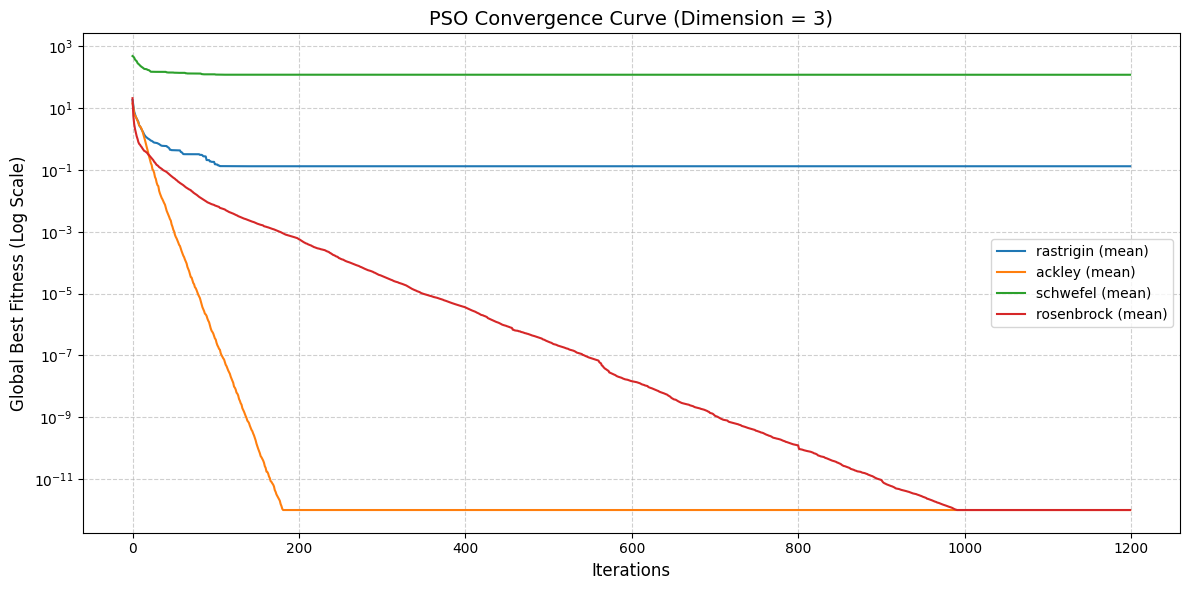

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

def benchmark_and_plot() -> None:
    dimension = 3

    test_cases = {
        "rastrigin": (-5.12, 5.12),   # 0,(0,0,0)
        "ackley": (-32.768, 32.768),  # 0,(0,0,0)
        "schwefel": (-500.0, 500.0),  # 0,(420,420,420)
        "rosenbrock": (-2.048, 2.048) # 0,(1,1,1)
    }

    iteration = 1200
    pop_size = 60
    runs = 30   # 跑30次

    plt.figure(figsize=(12, 6))

    for func, bounds in test_cases.items():
        print(f"\n🚀 Running {func} benchmark ({runs} runs)...")

        all_histories = []
        final_scores = []
        final_positions = []
        times = []

        for run in range(runs):
            print(f"\n  ▶ Run {run+1}/{runs}")

            np.random.seed(run)#可以重現結果

            start_time = time.time()

            optimizer = Swarm( num_particles=60, dim=3, BOUNDS=bounds, func_name=func)

            fitness_history = []

            for state in optimizer.simulate(steps=iteration):
                fitness_history.append(state['g_best_fitness'])

            elapsed = time.time() - start_time

            # ===== 單次結果 =====
            print(f"    Best g_best Score: {optimizer.g_best_fitness:.6e}")
            print(f"    Best g_best Position: {np.round(optimizer.g_best, 4)}")
            print(f"    Time: {elapsed:.4f} sec")

            # ===== 收集資料 =====
            all_histories.append(fitness_history)
            final_scores.append(optimizer.g_best_fitness)
            final_positions.append(optimizer.g_best)
            times.append(elapsed)

        # ===== 平均統計 =====
        mean_curve = np.mean(all_histories, axis=0)
        mean_score = np.mean(final_scores)
        std_score = np.std(final_scores)
        mean_time = np.mean(times)

        # ⭐ position 平均（逐維平均）
        mean_position = np.mean(final_positions, axis=0)

        # ===== 輸出平均結果 =====
        print(f"\n📊 {func} Summary ({runs} runs)")
        print(f"  Mean Best Score: {mean_score:.6e} ± {std_score:.2e}")
        print(f"  Mean Best Position: {np.round(mean_position, 4)}")
        print(f"  Mean Time: {mean_time:.4f} sec")

        # ===== 畫平均收斂曲線 =====
        mean_curve = np.maximum(mean_curve, 1e-12)  # 避免 log(0)
        plt.plot(mean_curve, label=f"{func} (mean)")

    # ===== 圖表設定 =====
    plt.title(f"PSO Convergence Curve (Dimension = {dimension})", fontsize=14)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Global Best Fitness (Log Scale)", fontsize=12)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    benchmark_and_plot()